In [52]:
import numpy as np
import pandas as pd
from ev_sim import plot

ann_arbor_bbox = (-83.81, 42.22, -83.67, 42.33)
washtenaw_bbox = (-84.17, 41.99, -83.50, 42.45)
se_michigan_bbox = (-84.2, 41.68, -82.4, 43.2)

detroit_basemap = plot.BasemapStyle(base_zoom=13, labels_zoom=12)
washtenaw_basemap = plot.BasemapStyle(base_zoom=12, labels_zoom=11)
se_michigan_basemap = plot.BasemapStyle(base_zoom=10, labels_zoom=9)

bboxes = {
    "ann-arbor": ann_arbor_bbox,
    "washtenaw": washtenaw_bbox,
    "se-michigan": se_michigan_bbox,
}

basemaps = {
    "washtenaw": washtenaw_basemap,
    "se-michigan": se_michigan_basemap,
    "detroit": detroit_basemap,
}

line_cols = ("pick_lon", "pick_lat", "drop_lon", "drop_lat")

In [53]:
REGION = "detroit"

bbox = bboxes.get(REGION)
basemap = basemaps.get(REGION)
frac = 0.2

df_all = pd.read_parquet(f"data/requests/{REGION}.parquet").sample(frac=frac)
df_internal = pd.read_parquet(f"output/semcog/internal-{REGION}-trips.parquet").sample(frac=frac)
df_external = pd.read_parquet(f"output/semcog/external-{REGION}-trips.parquet").sample(frac=frac)

for df in (df_all, df_internal, df_external):
    for col in line_cols:
        df[col] = np.rad2deg(df[col])

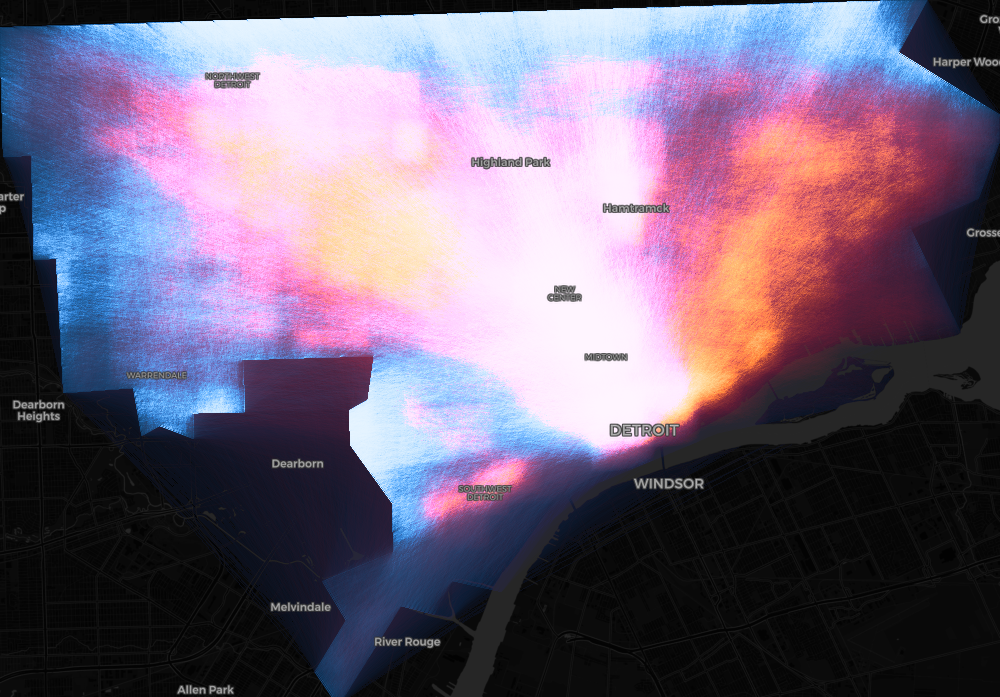

In [54]:
ax = plot.GeoPlot(width=1000, bbox_latlon=bbox, basemap_style=basemap, blend="lighten")
ax.add_lines(df_internal, *line_cols)
ax.add_lines(df_external, *line_cols, cmap=plot.cmap_blue)
ax.render()

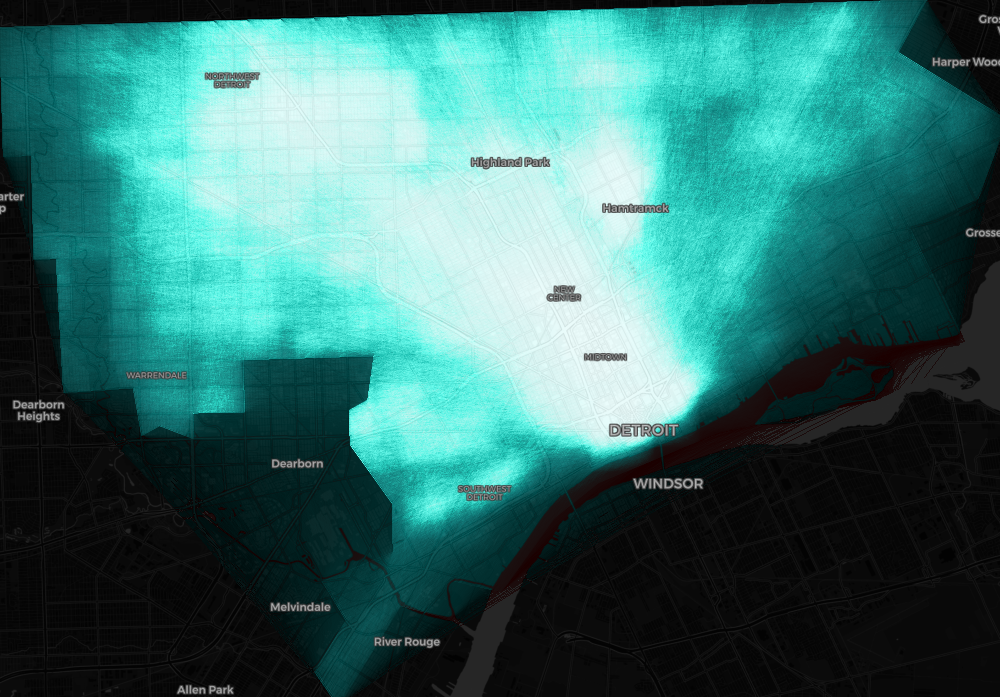

In [55]:
ax = plot.GeoPlot(width=1000, bbox_latlon=bbox, basemap_style=basemap, blend="difference")
ax.add_lines(df_all, *line_cols, cmap=plot.cmap_teal)
ax.render()

In [27]:
REGION = "ann-arbor"
REGION_NAME = REGION.replace("-", " ").title()

requests = pd.read_parquet(f"data/requests/{REGION}.parquet")
print(len(requests))
requests.head()

3346447


,created_at,pick_lat,pick_lon,drop_lat,drop_lon,pax,pick_hex,drop_hex,predicted_lm_dist
0,0,0.738629,-1.460671,0.738030,-1.461656,1,604233477973344255,604173502378934271,8.217588
1,0,0.737561,-1.462025,0.737482,-1.462059,1,604173502378934271,604173502378934271,1.238919
2,0,0.738694,-1.460979,0.738383,-1.461512,3,604233477973344255,604233477973344255,4.642469
3,1,0.737497,-1.461377,0.737588,-1.461326,1,604173502378934271,604173502378934271,1.365432
4,1,0.737176,-1.461526,0.737830,-1.460710,2,604233474215247871,604233478107561983,7.790916


(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'left': '# Requests versus Time'}>)

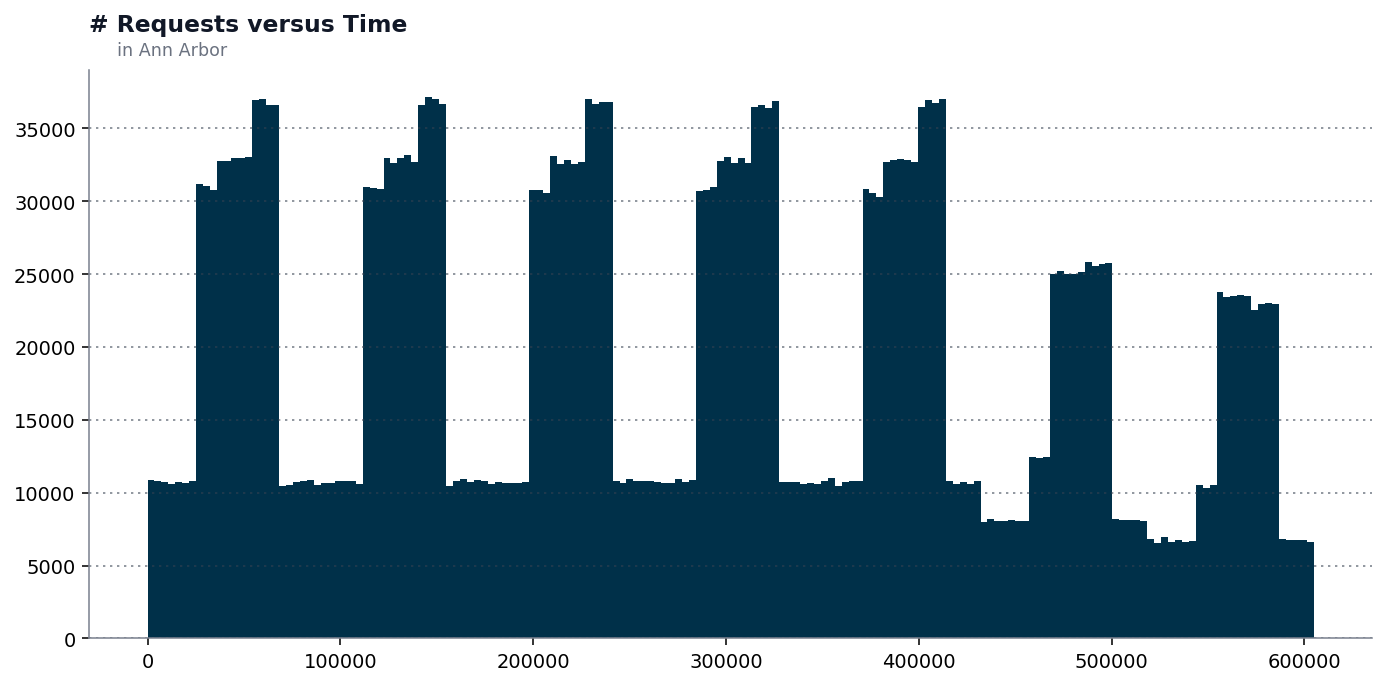

In [25]:
ax = plot.Plot("# Requests versus Time", subtitle=f"     in {REGION_NAME}", figsize=(10, 5))
ax.add_hist(requests["created_at"], bins=7 * 24, color="#003049", alpha=1)
ax.render()